# 01. AI-Assisted Causal Workflow

Modern AI systems can make a causal analyst faster, more organized, and more consistent. They can draft estimand cards, brainstorm candidate DAGs, summarize domain documents, generate diagnostic code, and turn estimates into stakeholder-ready memos.

They cannot, by themselves, make a causal claim credible.

This notebook introduces a disciplined workflow for using AI as a causal-analysis copilot. The main idea is simple: use AI to produce artifacts that a trained analyst can inspect, test, revise, and document. Do not use AI as a substitute for identification logic, domain knowledge, or statistical diagnostics.

Because this course can use local models up to roughly 32B parameters, we will also treat **model scale** as something to evaluate. Larger models may produce better causal artifacts, but scale does not remove the need for estimands, DAGs, diagnostics, and human review.

We will also compare model families selectively. A clean Qwen ladder is useful for scale comparisons, while Phi, Mistral, Gemma, and Llama models help us see whether different pretrained and instruction-tuned systems make different causal mistakes.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain where AI can help in a causal inference project and where it can mislead.
- Convert a vague business question into a structured causal estimand card.
- Use AI-style structured outputs without giving up analyst control.
- Build and critique a candidate DAG for an applied project.
- Run a lightweight data audit that checks treatment imbalance, timing, and bad-control risks.
- Compare a naive estimate with adjusted causal estimates in a simulated observational setting.
- Produce a decision memo that separates evidence, assumptions, limitations, and recommendations.
- Explain why model scale and model family can change AI-assisted causal work without making causal validation optional.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal inference requires validation, audit trails, and analyst judgment.

Treat model output as a draft artifact, not as causal evidence. A model may produce valid JSON with weak causal reasoning, or strong prose that fails schema validation.

When live calls are enabled, read the results as experiments about AI behavior:

- Did the model invent design details?
- Did it confuse prediction with causation?
- Did it recommend bad controls?
- Did it obey the schema?
- Did it surface missing information?
- Did it preserve uncertainty?

The goal is not to make every model output perfect. The goal is to learn how to build AI-assisted causal workflows that are auditable, constrained, and reviewed by a human analyst.

## 1. What AI Assistance Means in Causal Work

A useful way to think about AI in causal inference is to separate **artifact generation** from **causal authority**.

AI is useful for producing first drafts of:

- causal question decompositions,
- estimand cards,
- candidate DAGs,
- variable-role tables,
- data-audit checklists,
- method shortlists,
- analysis code skeletons,
- diagnostic narratives,
- executive memos.

The analyst remains responsible for:

- verifying domain assumptions,
- deciding which variables are pre-treatment,
- rejecting bad controls,
- checking overlap and measurement quality,
- choosing an identification strategy,
- interpreting uncertainty,
- communicating limitations honestly.

That boundary matters. AI can make a wrong causal analysis look polished. A polished wrong answer is still wrong.

## 2. The Workflow We Will Use

| Phase | AI can help with | Analyst must own | Main artifact |
|---|---|---|---|
| Question framing | Translate vague stakeholder language into treatment, outcome, unit, and time window | Decide whether the causal question is meaningful and actionable | Estimand card |
| Assumptions | Brainstorm mechanisms, confounders, mediators, colliders, and selection processes | Validate the DAG against domain knowledge | DAG and adjustment set |
| Data audit | Draft checks for missingness, timing, balance, leakage, and overlap | Decide whether the available data can support the design | Data-readiness report |
| Method choice | Shortlist feasible designs and state assumptions | Choose the design and reject invalid options | Design memo |
| Estimation | Generate reproducible code skeletons | Inspect diagnostics and decide if estimates are credible | Notebook and result table |
| Reporting | Draft concise narratives for decision makers | Prevent overclaiming and document uncertainty | Decision memo |

The rest of the notebook walks through these phases using a simulated industry example.

## 2.1. Model Scale and Model Family as Design Variables

In this course, the local LLM is not just infrastructure. It is also part of the analysis workflow we can study.

A useful model ladder is:

| Model tier | Example model | Role |
|---|---|---|
| Smoke test | `Qwen/Qwen2.5-0.5B-Instruct` | Prove the local generation pipeline works |
| Fast default | `Qwen/Qwen2.5-7B-Instruct` | Main working model for quick drafts of causal artifacts |
| Strong local model | `Qwen/Qwen2.5-14B-Instruct` | DAG critique, estimand cards, memos, and method review |
| Scale comparison | `Qwen/Qwen2.5-32B-Instruct` | Study how larger models change causal reasoning quality |
| Model-family comparison | `microsoft/Phi-3.5-mini-instruct` | Compact non-Qwen comparison |
| Model-family comparison | `mistralai/Mistral-7B-Instruct-v0.3` | Alternative 7B instruct model |
| Strong non-Qwen comparison | `mistralai/Mistral-Small-3.1-24B-Instruct-2503` | Larger Mistral comparison below the 32B ceiling |
| Large non-Qwen comparison | `google/gemma-3-27b-it` | Strong Gemma-family comparison point |
| Industry-standard baseline | `meta-llama/Meta-Llama-3.1-8B-Instruct` | Common local instruct-model baseline |

For now, treat `Qwen/Qwen2.5-7B-Instruct` as the practical working default and treat the larger and alternative-family models as comparison points. Notebook 02 will benchmark this ladder directly and evaluate whether scale or model family changes causal artifact quality. The result should be treated as evidence from a task-specific rubric, not as a universal ranking of models.

The point is not to assume that 32B is automatically correct or that one model family is universally best. The point is to run the same causal task across model scales and model families, then evaluate the outputs with causal criteria:

- Did the model state a clear treatment, outcome, unit, and time window?
- Did it distinguish association from causation?
- Did it identify plausible confounders?
- Did it avoid controlling for post-treatment variables?
- Did it state assumptions that are required but untestable?
- Did it avoid inventing facts not present in the prompt?
- Did it communicate uncertainty without weakening the decision relevance?

This framing turns local LLM scale and model-family choice into teachable objects. Bigger models may be more fluent and more complete, and different model families may have different habits, but causal validity still comes from the workflow.


## 3. Setup

The notebook uses standard scientific Python packages plus `pydantic` for structured artifacts and `graphviz` for DAGs. No live LLM API call is required. Where an AI assistant would normally generate text or JSON, we use a simulated assistant output so the notebook remains reproducible.

In [1]:
import warnings
from textwrap import dedent

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from pydantic import BaseModel, Field, ValidationError
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', '{:.3f}'.format)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir='LR'):
    graph = graphviz.Digraph(format='svg')
    graph.attr(rankdir=rankdir, bgcolor='white', pad='0.2')
    graph.attr('node', shape='box', style='rounded,filled', color='#334155', fontname='Helvetica')
    graph.attr('edge', color='#475569', arrowsize='0.8')

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, '#eef2ff'))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc='t', fontsize='18', fontname='Helvetica-Bold')
    return graph


def risk_difference(frame, outcome, treatment):
    treated = frame.loc[frame[treatment] == 1, outcome]
    control = frame.loc[frame[treatment] == 0, outcome]
    estimate = treated.mean() - control.mean()
    se = np.sqrt(treated.var(ddof=1) / treated.size + control.var(ddof=1) / control.size)
    return {
        'estimate': estimate,
        'std_error': se,
        'ci_low': estimate - 1.96 * se,
        'ci_high': estimate + 1.96 * se,
        'treated_mean': treated.mean(),
        'control_mean': control.mean(),
        'n_treated': treated.size,
        'n_control': control.size,
    }


def standardized_mean_difference(frame, variable, treatment='outreach'):
    treated = frame.loc[frame[treatment] == 1, variable]
    control = frame.loc[frame[treatment] == 0, variable]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd


def plot_estimates(table, title, true_value=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    y = np.arange(len(table))
    ax.errorbar(
        table['estimate'],
        y,
        xerr=[table['estimate'] - table['ci_low'], table['ci_high'] - table['estimate']],
        fmt='o',
        color='#2563eb',
        ecolor='#93c5fd',
        capsize=4,
    )
    if true_value is not None:
        ax.axvline(true_value, color='#16a34a', linestyle='--', label='true ATE in simulation')
    ax.axvline(0, color='#64748b', linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(table['method'])
    ax.set_xlabel('Effect on churn risk')
    ax.set_title(title)
    if true_value is not None:
        ax.legend(loc='best')
    plt.tight_layout()
    return fig, ax

## 4. Running Example: Proactive Retention Outreach

Imagine a SaaS company asks the data science team:

> Did proactive customer-success outreach reduce churn last quarter?

This sounds simple, but it is not yet a causal question. We need to clarify:

- What exactly counts as outreach?
- Which customers were eligible?
- What is the outcome and over what time window?
- Was outreach randomly assigned?
- Did customer-success managers target accounts that already looked risky?
- Which variables were measured before outreach?
- Which variables were caused by outreach and should not be adjusted for?

We will simulate data where outreach truly reduces churn, but high-risk customers are more likely to receive outreach. That creates a classic observational-evaluation problem: the naive comparison will be badly biased.

In [3]:
rng = np.random.default_rng(42)
n = 6_000

company_size = rng.lognormal(mean=4.2, sigma=0.75, size=n)
tenure_months = np.clip(rng.gamma(shape=2.8, scale=8, size=n), 1, 96)
usage_score = np.clip(rng.normal(loc=0, scale=1, size=n), -3, 3)
prior_tickets = rng.poisson(np.exp(0.35 - 0.35 * usage_score + 0.25 * (company_size > 120)))
health_score = np.clip(
    67 + 9 * usage_score - 3.8 * prior_tickets + 0.06 * tenure_months + rng.normal(0, 8, n),
    1,
    99,
)
region = rng.choice(['North America', 'Europe', 'APAC', 'Latin America'], size=n, p=[0.45, 0.25, 0.22, 0.08])
segment = pd.cut(company_size, bins=[0, 60, 140, np.inf], labels=['small', 'mid-market', 'enterprise'])

region_risk = pd.Series(region).map(
    {'North America': 0.00, 'Europe': -0.08, 'APAC': 0.05, 'Latin America': 0.12}
).to_numpy()

# Historical targeting: riskier and larger accounts were more likely to receive proactive outreach.
propensity = sigmoid(
    -1.15
    + 0.045 * (70 - health_score)
    + 0.19 * prior_tickets
    + 0.45 * (company_size > 120)
    - 0.015 * tenure_months
    + region_risk
)
outreach = rng.binomial(1, propensity)

# Baseline churn risk without outreach.
p_churn_without = sigmoid(
    -1.65
    + 0.055 * (70 - health_score)
    + 0.15 * prior_tickets
    - 0.018 * tenure_months
    + region_risk
)

# True causal effect: outreach reduces churn more for fragile accounts.
true_individual_effect = (
    -0.025
    - 0.055 * (health_score < 55)
    - 0.025 * (prior_tickets >= 4)
    - 0.015 * (company_size > 120)
)
p_churn_with = np.clip(p_churn_without + true_individual_effect, 0.01, 0.95)
churn = rng.binomial(1, np.where(outreach == 1, p_churn_with, p_churn_without))

df = pd.DataFrame(
    {
        'account_id': np.arange(1, n + 1),
        'outreach': outreach,
        'churn': churn,
        'company_size': company_size,
        'tenure_months': tenure_months,
        'usage_score': usage_score,
        'prior_tickets': prior_tickets,
        'health_score': health_score,
        'region': region,
        'segment': segment.astype(str),
        'propensity_true': propensity,
        'true_individual_effect': true_individual_effect,
        'p_churn_without': p_churn_without,
        'p_churn_with': p_churn_with,
    }
)

true_ate = df['true_individual_effect'].mean()
df.head()

,account_id,outreach,churn,company_size,tenure_months,usage_score,prior_tickets,health_score,region,segment,propensity_true,true_individual_effect,p_churn_without,p_churn_with
0,1,0,1,83.809,22.699,-1.180,2,49.995,North America,mid-market,0.448,-0.080,0.341,0.261
1,2,0,0,30.570,32.702,-0.084,3,65.911,North America,small,0.292,-0.025,0.173,0.148
2,3,1,0,117.078,9.620,0.341,2,66.146,Europe,mid-market,0.306,-0.025,0.199,0.174
3,4,1,1,135.020,17.459,0.163,2,63.467,APAC,mid-market,0.441,-0.040,0.222,0.182
4,5,1,1,15.436,5.464,-1.711,3,42.650,APAC,small,0.650,-0.080,0.564,0.484


In [4]:
overview = pd.DataFrame(
    {
        'quantity': [
            'accounts',
            'outreach rate',
            'observed churn rate',
            'true ATE in simulation',
            'mean baseline churn risk among treated',
            'mean baseline churn risk among controls',
        ],
        'value': [
            len(df),
            df['outreach'].mean(),
            df['churn'].mean(),
            true_ate,
            df.loc[df['outreach'] == 1, 'p_churn_without'].mean(),
            df.loc[df['outreach'] == 0, 'p_churn_without'].mean(),
        ],
    }
)
overview

,quantity,value
0,accounts,6000.000
1,outreach rate,0.340
2,observed churn rate,0.222
3,true ATE in simulation,-0.046
4,mean baseline churn risk among treated,0.321
5,mean baseline churn risk among controls,0.189


### Discussion

The simulated true average treatment effect is negative: outreach reduces churn risk. However, the treated accounts are much riskier at baseline because the business targeted accounts that already looked vulnerable.

This is exactly the kind of setting where AI can be useful and dangerous at the same time. Useful because it can help us organize a careful causal design. Dangerous because, if prompted carelessly, it may produce a confident narrative from the naive comparison.

## 5. The Naive AI Answer We Do Not Want

Suppose someone asks an AI assistant to summarize whether outreach worked and gives it only the treated and untreated churn rates. It might produce an answer like this:

> Outreach accounts churned more than non-outreach accounts, so the program appears harmful.

That answer is superficially data-driven but causally wrong. It compares high-risk targeted accounts to lower-risk non-targeted accounts.

In [5]:
naive = risk_difference(df, outcome='churn', treatment='outreach')

pd.DataFrame(
    [
        {
            'treated churn': naive['treated_mean'],
            'control churn': naive['control_mean'],
            'naive risk difference': naive['estimate'],
            'ci low': naive['ci_low'],
            'ci high': naive['ci_high'],
            'n treated': naive['n_treated'],
            'n control': naive['n_control'],
        }
    ]
)

,treated churn,control churn,naive risk difference,ci low,ci high,n treated,n control
0,0.273,0.195,0.078,0.056,0.101,2038,3962


With this seed, the naive estimate says outreach is associated with **higher** churn. But we know the true simulated effect is negative. The sign is wrong because outreach was targeted toward accounts at high risk of churn.

This is the first rule of AI-assisted causal work:

> Never let the language model turn an associational comparison into a causal conclusion.

## 6. AI-Assisted Estimand Card

A better first use of AI is not to ask for the answer. It is to ask for a structured causal design artifact.

Below we define an estimand-card schema. In a live workflow, an LLM could draft JSON matching this schema from a project brief. The analyst would then edit and approve it.

In [6]:
class EstimandCard(BaseModel):
    business_question: str
    causal_question: str
    unit: str
    treatment: str
    control_condition: str
    outcome: str
    time_window: str
    target_population: str
    estimand: str
    required_assumptions: list[str] = Field(default_factory=list)
    likely_threats: list[str] = Field(default_factory=list)
    variables_to_audit: list[str] = Field(default_factory=list)


simulated_ai_output = {
    'business_question': 'Did proactive customer-success outreach reduce churn last quarter?',
    'causal_question': 'What was the average causal effect of proactive outreach on 90-day churn among eligible SaaS accounts?',
    'unit': 'customer account',
    'treatment': 'receiving proactive customer-success outreach during the intervention month',
    'control_condition': 'not receiving proactive outreach during the same eligibility window',
    'outcome': 'churn within 90 days after the outreach eligibility date',
    'time_window': 'accounts eligible during the prior quarter; outcome measured over the following 90 days',
    'target_population': 'eligible active SaaS accounts that could have received proactive outreach',
    'estimand': 'average treatment effect on churn risk for the eligible-account population',
    'required_assumptions': [
        'all common causes of outreach assignment and churn are observed and adjusted for',
        'each account has a positive probability of receiving and not receiving outreach conditional on covariates',
        'pre-treatment covariates are measured before outreach assignment',
        'outreach for one account does not materially affect another account churn outcome',
    ],
    'likely_threats': [
        'customer-success managers targeted accounts using unobserved knowledge',
        'usage changes after outreach could be mistakenly controlled for',
        'enterprise accounts may have different overlap than small accounts',
        'churn timing could overlap with outreach timing for some accounts',
    ],
    'variables_to_audit': [
        'account health score',
        'prior support tickets',
        'usage before outreach',
        'company size',
        'tenure',
        'region',
        'post-outreach engagement variables',
    ],
}

estimand_card = EstimandCard.model_validate(simulated_ai_output)
estimand_card

EstimandCard(business_question='Did proactive customer-success outreach reduce churn last quarter?', causal_question='What was the average causal effect of proactive outreach on 90-day churn among eligible SaaS accounts?', unit='customer account', treatment='receiving proactive customer-success outreach during the intervention month', control_condition='not receiving proactive outreach during the same eligibility window', outcome='churn within 90 days after the outreach eligibility date', time_window='accounts eligible during the prior quarter; outcome measured over the following 90 days', target_population='eligible active SaaS accounts that could have received proactive outreach', estimand='average treatment effect on churn risk for the eligible-account population', required_assumptions=['all common causes of outreach assignment and churn are observed and adjusted for', 'each account has a positive probability of receiving and not receiving outreach conditional on covariates', 'pre-t

In [7]:
display(Markdown(
    f'''
### Estimand Card

**Business question:** {estimand_card.business_question}

**Causal question:** {estimand_card.causal_question}

**Unit:** {estimand_card.unit}

**Treatment:** {estimand_card.treatment}

**Control condition:** {estimand_card.control_condition}

**Outcome:** {estimand_card.outcome}

**Target population:** {estimand_card.target_population}

**Estimand:** {estimand_card.estimand}
    '''
))


### Estimand Card

**Business question:** Did proactive customer-success outreach reduce churn last quarter?

**Causal question:** What was the average causal effect of proactive outreach on 90-day churn among eligible SaaS accounts?

**Unit:** customer account

**Treatment:** receiving proactive customer-success outreach during the intervention month

**Control condition:** not receiving proactive outreach during the same eligibility window

**Outcome:** churn within 90 days after the outreach eligibility date

**Target population:** eligible active SaaS accounts that could have received proactive outreach

**Estimand:** average treatment effect on churn risk for the eligible-account population
    

### Discussion

The value of the estimand card is not that it is final. Its value is that it forces ambiguity into the open.

An analyst should now ask stakeholders:

- Were all eligible accounts logged, or only contacted accounts?
- Was the eligibility date recorded before outreach?
- Did managers choose accounts using notes or informal knowledge not present in the dataset?
- Are there accounts that could never receive outreach because of staffing or geography?
- Are post-outreach usage metrics being mixed into the covariate table?

AI helped us get to the right conversation faster. It did not settle the causal question.

## 7. Prompt Pattern: Ask for Artifacts, Not Answers

A weak prompt asks:

> Did outreach reduce churn?

A stronger prompt asks:

```text
You are helping draft a causal design document. Do not estimate the answer.
Return a structured estimand card with treatment, outcome, unit, target population,
time window, likely confounders, bad-control risks, required assumptions, and open questions.
Flag anything that cannot be determined from the brief.
```

This pattern is safer because it channels the model toward design support rather than conclusion generation.

## 8. AI-Assisted DAG Brainstorming

The next useful artifact is a candidate DAG. A language model can brainstorm plausible relationships from domain text. The analyst must then edit the graph.

For this example, a plausible causal story is:

- weak account health, many support tickets, low usage, size, tenure, region, and segment influence whether an account receives outreach;
- those same variables also influence churn;
- outreach may influence post-outreach engagement, support touchpoints, and eventual churn;
- post-outreach engagement is not a pre-treatment confounder.

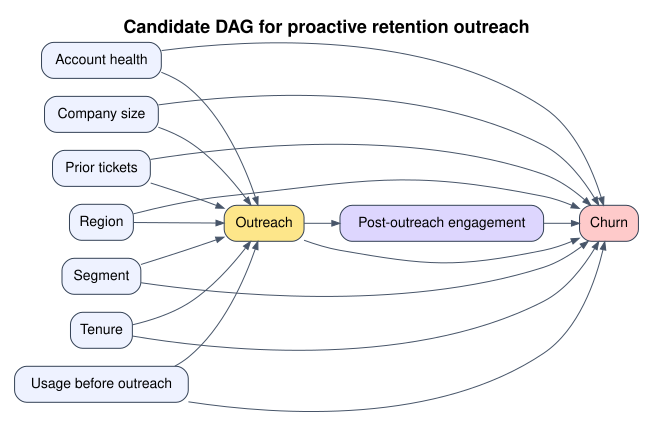

In [8]:
edges = [
    ('Account health', 'Outreach'),
    ('Account health', 'Churn'),
    ('Prior tickets', 'Outreach'),
    ('Prior tickets', 'Churn'),
    ('Usage before outreach', 'Outreach'),
    ('Usage before outreach', 'Churn'),
    ('Company size', 'Outreach'),
    ('Company size', 'Churn'),
    ('Tenure', 'Outreach'),
    ('Tenure', 'Churn'),
    ('Region', 'Outreach'),
    ('Region', 'Churn'),
    ('Segment', 'Outreach'),
    ('Segment', 'Churn'),
    ('Outreach', 'Post-outreach engagement'),
    ('Post-outreach engagement', 'Churn'),
    ('Outreach', 'Churn'),
]

node_colors = {
    'Outreach': '#fde68a',
    'Churn': '#fecaca',
    'Post-outreach engagement': '#ddd6fe',
}

make_dag(edges, title='Candidate DAG for proactive retention outreach', node_colors=node_colors)

### Discussion

The DAG makes one critical warning visible: **post-outreach engagement is downstream of the treatment**. If we control for it while estimating the total effect of outreach, we block part of the causal pathway and can introduce post-treatment bias.

A good AI assistant should not merely draw a DAG. It should also return a variable-role table and explicitly flag variables that are dangerous to adjust for.

In [9]:
variable_roles = pd.DataFrame(
    [
        ('health_score', 'pre-treatment confounder', 'adjust'),
        ('prior_tickets', 'pre-treatment confounder', 'adjust'),
        ('usage_score', 'pre-treatment confounder', 'adjust'),
        ('company_size', 'pre-treatment confounder or precision variable', 'adjust'),
        ('tenure_months', 'pre-treatment confounder or precision variable', 'adjust'),
        ('region', 'pre-treatment confounder or operational constraint', 'adjust'),
        ('segment', 'pre-treatment confounder or effect modifier', 'adjust and inspect heterogeneity'),
        ('post_outreach_engagement', 'mediator or post-treatment variable', 'do not adjust for total effect'),
        ('followup_calls_after_outreach', 'post-treatment variable', 'do not adjust for total effect'),
        ('manager_notes_after_outreach', 'post-treatment measurement', 'do not adjust for total effect'),
    ],
    columns=['variable', 'role', 'recommendation'],
)

variable_roles

,variable,role,recommendation
0,health_score,pre-treatment confounder,adjust
1,prior_tickets,pre-treatment confounder,adjust
2,usage_score,pre-treatment confounder,adjust
3,company_size,pre-treatment confounder or precision variable,adjust
4,tenure_months,pre-treatment confounder or precision variable,adjust
5,region,pre-treatment confounder or operational constr...,adjust
6,segment,pre-treatment confounder or effect modifier,adjust and inspect heterogeneity
7,post_outreach_engagement,mediator or post-treatment variable,do not adjust for total effect
8,followup_calls_after_outreach,post-treatment variable,do not adjust for total effect
9,manager_notes_after_outreach,post-treatment measurement,do not adjust for total effect


## 9. AI-Assisted Data Audit

Before fitting models, ask the assistant to draft a data audit. Then make the audit executable.

For this example, the most important questions are:

- Are treated and untreated accounts comparable on pre-treatment variables?
- Is there enough overlap in treatment propensities?
- Are all adjustment variables measured before outreach?
- Are any post-treatment variables accidentally included?
- Are there missing values or segment-specific data problems?

We will start with balance on pre-treatment covariates.

In [10]:
numeric_covariates = ['company_size', 'tenure_months', 'usage_score', 'prior_tickets', 'health_score']

balance_rows = []
for variable in numeric_covariates:
    balance_rows.append(
        {
            'variable': variable,
            'treated_mean': df.loc[df['outreach'] == 1, variable].mean(),
            'control_mean': df.loc[df['outreach'] == 0, variable].mean(),
            'std_mean_difference': standardized_mean_difference(df, variable),
        }
    )

balance = pd.DataFrame(balance_rows).sort_values('std_mean_difference', key=np.abs, ascending=False)
balance

,variable,treated_mean,control_mean,std_mean_difference
4,health_score,55.368,66.152,-0.779
3,prior_tickets,2.187,1.282,0.636
2,usage_score,-0.304,0.208,-0.528
0,company_size,99.240,82.109,0.217
1,tenure_months,20.827,23.281,-0.185


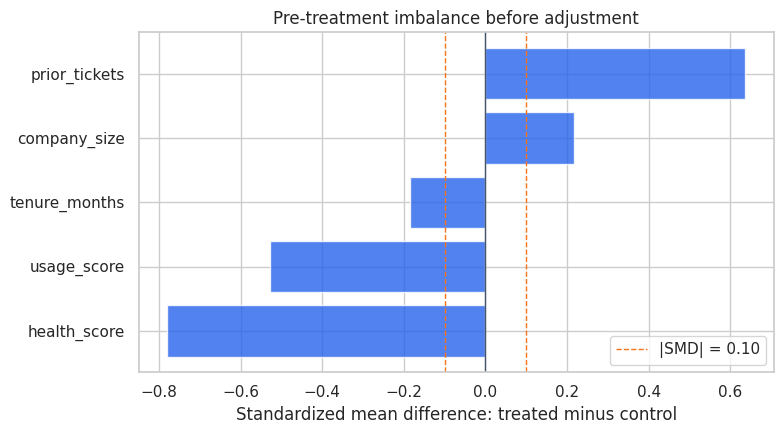

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_data = balance.sort_values('std_mean_difference')
ax.barh(plot_data['variable'], plot_data['std_mean_difference'], color='#2563eb', alpha=0.8)
ax.axvline(0.1, color='#f97316', linestyle='--', linewidth=1, label='|SMD| = 0.10')
ax.axvline(-0.1, color='#f97316', linestyle='--', linewidth=1)
ax.axvline(0, color='#475569', linewidth=1)
ax.set_title('Pre-treatment imbalance before adjustment')
ax.set_xlabel('Standardized mean difference: treated minus control')
ax.legend(loc='lower right')
plt.tight_layout()

### Discussion

The balance table should show meaningful imbalance. Treated accounts tend to have lower health scores, more prior tickets, and larger company size. That is the business targeting rule showing up in the data.

An AI assistant can help describe this imbalance, but the analyst must connect the imbalance to the identification strategy. If the treated accounts were already more likely to churn, a naive treated-versus-control comparison is not credible.

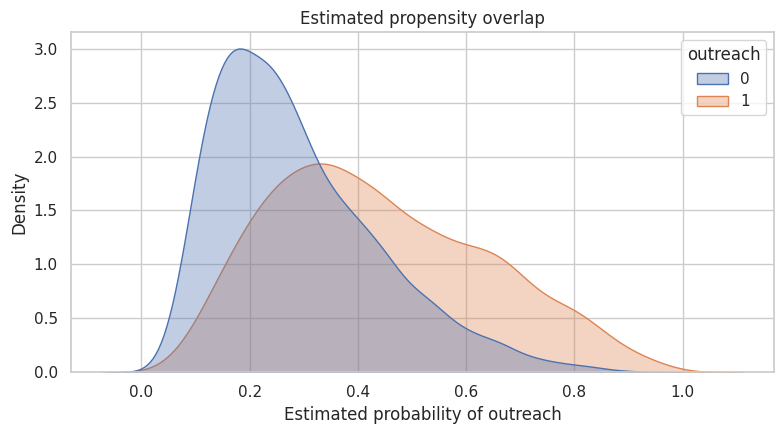

In [12]:
feature_cols = ['company_size', 'tenure_months', 'usage_score', 'prior_tickets', 'health_score', 'region', 'segment']
num_cols = ['company_size', 'tenure_months', 'usage_score', 'prior_tickets', 'health_score']
cat_cols = ['region', 'segment']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ]
)

propensity_model = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('model', LogisticRegression(max_iter=1_000)),
    ]
)

propensity_model.fit(df[feature_cols], df['outreach'])
df['propensity_hat'] = np.clip(propensity_model.predict_proba(df[feature_cols])[:, 1], 0.02, 0.98)

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.kdeplot(data=df, x='propensity_hat', hue='outreach', common_norm=False, fill=True, alpha=0.35, ax=ax)
ax.set_title('Estimated propensity overlap')
ax.set_xlabel('Estimated probability of outreach')
plt.tight_layout()

## 10. AI-Assisted Method Selection

Method selection should be framed as a design question, not a package-selection question.

The assistant can draft a shortlist, but it should include reasons to reject methods. In many real projects, the most valuable AI output is not the method it recommends. It is the invalid methods it helps you rule out.

In [13]:
method_shortlist = pd.DataFrame(
    [
        {
            'method': 'Randomized experiment',
            'could use here?': 'not for historical estimate',
            'why': 'outreach was already assigned non-randomly; useful for a future validation test',
        },
        {
            'method': 'Regression adjustment',
            'could use here?': 'yes, as baseline',
            'why': 'pre-treatment covariates that influenced assignment are available',
        },
        {
            'method': 'Propensity weighting',
            'could use here?': 'yes, with overlap diagnostics',
            'why': 'assignment appears predictable from observed pre-treatment variables',
        },
        {
            'method': 'Doubly robust estimation',
            'could use here?': 'yes, as robustness check',
            'why': 'combines outcome modeling with propensity correction',
        },
        {
            'method': 'Difference-in-differences',
            'could use here?': 'not from current data alone',
            'why': 'would need credible pre/post panel structure and comparison trend evidence',
        },
        {
            'method': 'Regression discontinuity',
            'could use here?': 'not unless assignment used a sharp cutoff',
            'why': 'no documented threshold rule is available',
        },
    ]
)

method_shortlist

,method,could use here?,why
0,Randomized experiment,not for historical estimate,outreach was already assigned non-randomly; us...
1,Regression adjustment,"yes, as baseline",pre-treatment covariates that influenced assig...
2,Propensity weighting,"yes, with overlap diagnostics",assignment appears predictable from observed p...
3,Doubly robust estimation,"yes, as robustness check",combines outcome modeling with propensity corr...
4,Difference-in-differences,not from current data alone,would need credible pre/post panel structure a...
5,Regression discontinuity,not unless assignment used a sharp cutoff,no documented threshold rule is available


## 11. Estimation: Naive, Adjusted, Weighted, and Doubly Robust

This is not a full lecture on each estimator. The purpose is to show how the workflow changes the analysis.

We will compare:

- naive difference in churn rates,
- regression adjustment,
- inverse propensity weighting,
- a simple doubly robust estimator.

Because the data are simulated, we also know the true ATE. In real data, we would not have that luxury.

In [14]:
# 1. Naive comparison
naive_stats = risk_difference(df, outcome='churn', treatment='outreach')

# 2. Regression-adjusted linear probability model
reg_model = smf.ols(
    'churn ~ outreach + company_size + tenure_months + usage_score + prior_tickets + health_score + C(region) + C(segment)',
    data=df,
).fit(cov_type='HC3')

# 3. Inverse propensity weighting for the ATE
e = df['propensity_hat'].to_numpy()
t = df['outreach'].to_numpy()
y = df['churn'].to_numpy()
ipw_estimate = np.mean(t * y / e - (1 - t) * y / (1 - e))

# Approximate standard error by nonparametric bootstrap for the IPW estimate.
boot_rng = np.random.default_rng(123)
boot_ipw = []
for _ in range(300):
    idx = boot_rng.integers(0, len(df), len(df))
    boot_ipw.append(np.mean(t[idx] * y[idx] / e[idx] - (1 - t[idx]) * y[idx] / (1 - e[idx])))
ipw_se = np.std(boot_ipw, ddof=1)

# 4. Simple doubly robust estimator using separate outcome models.
outcome_model_control = Pipeline(
    steps=[('preprocess', preprocess), ('model', LogisticRegression(max_iter=1_000))]
)
outcome_model_treated = Pipeline(
    steps=[('preprocess', preprocess), ('model', LogisticRegression(max_iter=1_000))]
)

outcome_model_control.fit(df.loc[df['outreach'] == 0, feature_cols], df.loc[df['outreach'] == 0, 'churn'])
outcome_model_treated.fit(df.loc[df['outreach'] == 1, feature_cols], df.loc[df['outreach'] == 1, 'churn'])

mu0 = outcome_model_control.predict_proba(df[feature_cols])[:, 1]
mu1 = outcome_model_treated.predict_proba(df[feature_cols])[:, 1]
aipw_scores = mu1 - mu0 + t * (y - mu1) / e - (1 - t) * (y - mu0) / (1 - e)
aipw_estimate = aipw_scores.mean()
aipw_se = aipw_scores.std(ddof=1) / np.sqrt(len(aipw_scores))

estimate_table = pd.DataFrame(
    [
        {
            'method': 'Naive difference',
            'estimate': naive_stats['estimate'],
            'std_error': naive_stats['std_error'],
            'ci_low': naive_stats['ci_low'],
            'ci_high': naive_stats['ci_high'],
        },
        {
            'method': 'Regression adjustment',
            'estimate': reg_model.params['outreach'],
            'std_error': reg_model.bse['outreach'],
            'ci_low': reg_model.conf_int().loc['outreach', 0],
            'ci_high': reg_model.conf_int().loc['outreach', 1],
        },
        {
            'method': 'IPW',
            'estimate': ipw_estimate,
            'std_error': ipw_se,
            'ci_low': ipw_estimate - 1.96 * ipw_se,
            'ci_high': ipw_estimate + 1.96 * ipw_se,
        },
        {
            'method': 'Doubly robust',
            'estimate': aipw_estimate,
            'std_error': aipw_se,
            'ci_low': aipw_estimate - 1.96 * aipw_se,
            'ci_high': aipw_estimate + 1.96 * aipw_se,
        },
    ]
)

estimate_table

,method,estimate,std_error,ci_low,ci_high
0,Naive difference,0.078,0.012,0.056,0.101
1,Regression adjustment,-0.044,0.012,-0.067,-0.021
2,IPW,-0.045,0.014,-0.072,-0.018
3,Doubly robust,-0.047,0.011,-0.068,-0.026


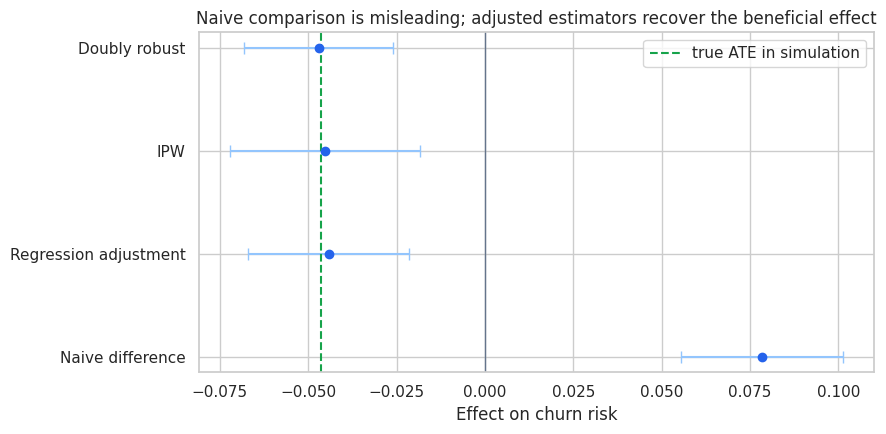

In [15]:
plot_estimates(
    estimate_table,
    title='Naive comparison is misleading; adjusted estimators recover the beneficial effect',
    true_value=true_ate,
);

### Discussion

The naive estimate says outreach increased churn. The adjusted estimators move in the opposite direction and line up closely with the true simulated effect.

This is the point of the workflow:

- The estimand card clarified the target quantity.
- The DAG clarified which variables were plausible confounders and which were post-treatment.
- The balance audit showed that treatment was targeted to high-risk accounts.
- The method shortlist justified adjustment and weighting approaches.
- The estimates became interpretable only after the design work was explicit.

AI can help produce each artifact. But the credibility comes from the causal design, not from the AI system.

## 12. Guardrails for AI-Generated Causal Code

If you ask an AI assistant to generate code, require the code to include guardrails. A good instruction is:

```text
Generate estimation code only after restating the estimand and listing the adjustment variables.
Do not include post-treatment variables in the adjustment set.
Include balance diagnostics, overlap diagnostics, and a result table with confidence intervals.
Mark any assumption that cannot be tested from the data.
```

The goal is to make unsafe code harder to produce silently.

In [16]:
diagnostic_checklist = pd.DataFrame(
    [
        ('Estimand stated before estimation', 'yes', 'ATE on 90-day churn risk among eligible accounts'),
        ('Treatment measured before outcome', 'needs source-system confirmation', 'simulated data satisfy this by construction'),
        ('Adjustment variables are pre-treatment', 'mostly yes', 'post-outreach engagement explicitly excluded'),
        ('Balance checked', 'yes', 'large initial imbalance found'),
        ('Overlap checked', 'yes', 'estimated propensity distribution plotted'),
        ('Multiple estimators compared', 'yes', 'regression, IPW, and doubly robust estimates'),
        ('Unobserved targeting assessed', 'open risk', 'manager notes and informal risk signals may not be observed'),
        ('Decision caveats documented', 'yes', 'memo should distinguish evidence from assumptions'),
    ],
    columns=['check', 'status', 'notes'],
)

diagnostic_checklist

,check,status,notes
0,Estimand stated before estimation,yes,ATE on 90-day churn risk among eligible accounts
1,Treatment measured before outcome,needs source-system confirmation,simulated data satisfy this by construction
2,Adjustment variables are pre-treatment,mostly yes,post-outreach engagement explicitly excluded
3,Balance checked,yes,large initial imbalance found
4,Overlap checked,yes,estimated propensity distribution plotted
5,Multiple estimators compared,yes,"regression, IPW, and doubly robust estimates"
6,Unobserved targeting assessed,open risk,manager notes and informal risk signals may no...
7,Decision caveats documented,yes,memo should distinguish evidence from assumptions


## 13. AI-Assisted Decision Memo

Finally, AI can help draft a decision memo. The memo should not hide assumptions. It should make them prominent.

Below is a simple deterministic memo generator. In a live workflow, an LLM could draft prose from the same structured inputs, but the analyst should review every claim.

In [17]:
best_row = estimate_table.loc[estimate_table['method'] == 'Doubly robust'].iloc[0]

memo = f'''
### Draft Decision Memo

**Question.** Did proactive customer-success outreach reduce 90-day churn among eligible accounts?

**Estimand.** Average treatment effect of outreach on churn risk for eligible accounts in the analysis window.

**Design.** Historical outreach was not randomized. Outreach was targeted toward riskier accounts, so the naive comparison is not credible. We used pre-treatment account characteristics to adjust for observed targeting: company size, tenure, usage before outreach, prior support tickets, account health, region, and segment.

**Key diagnostic.** Treated accounts were meaningfully higher risk before outreach. This explains why the naive comparison points in the wrong direction.

**Main estimate.** The doubly robust estimate suggests outreach changed churn risk by {best_row['estimate']:.1%} points, with an approximate 95% interval from {best_row['ci_low']:.1%} to {best_row['ci_high']:.1%} points.

**Interpretation.** Under the assumption that observed pre-treatment variables capture the important targeting logic, proactive outreach appears to reduce churn. The estimate should be interpreted as evidence from an observational design, not as strong as a randomized experiment.

**Main limitation.** If customer-success managers selected accounts using unrecorded information, residual confounding may remain.

**Recommendation.** Continue the program for high-risk eligible accounts, but run a randomized holdout or phased rollout in the next cycle to validate impact with stronger design evidence.
'''

display(Markdown(memo))


### Draft Decision Memo

**Question.** Did proactive customer-success outreach reduce 90-day churn among eligible accounts?

**Estimand.** Average treatment effect of outreach on churn risk for eligible accounts in the analysis window.

**Design.** Historical outreach was not randomized. Outreach was targeted toward riskier accounts, so the naive comparison is not credible. We used pre-treatment account characteristics to adjust for observed targeting: company size, tenure, usage before outreach, prior support tickets, account health, region, and segment.

**Key diagnostic.** Treated accounts were meaningfully higher risk before outreach. This explains why the naive comparison points in the wrong direction.

**Main estimate.** The doubly robust estimate suggests outreach changed churn risk by -4.7% points, with an approximate 95% interval from -6.8% to -2.6% points.

**Interpretation.** Under the assumption that observed pre-treatment variables capture the important targeting logic, proactive outreach appears to reduce churn. The estimate should be interpreted as evidence from an observational design, not as strong as a randomized experiment.

**Main limitation.** If customer-success managers selected accounts using unrecorded information, residual confounding may remain.

**Recommendation.** Continue the program for high-risk eligible accounts, but run a randomized holdout or phased rollout in the next cycle to validate impact with stronger design evidence.


## 14. Governance: What to Save From an AI-Assisted Analysis

A serious AI-assisted causal workflow should leave an audit trail. Save the artifacts, not just the final estimate.

Recommended artifacts:

- original stakeholder brief,
- prompts used to generate estimand cards or DAG drafts,
- structured AI outputs,
- analyst edits to those outputs,
- final estimand card,
- final DAG or variable-role table,
- data audit results,
- excluded variables and reasons,
- estimation code,
- diagnostics and robustness checks,
- final memo with limitations.

This discipline protects the analyst. It also makes AI assistance more credible because stakeholders can see the chain from question to design to evidence.

## 15. Key Takeaways

- AI should help create reviewable causal artifacts, not directly manufacture causal conclusions.
- The right first output is often an estimand card, not an estimate.
- DAGs and variable-role tables are especially useful because they expose bad-control risks.
- Data audits should be executable, not only prose checklists.
- Naive comparisons can be badly wrong when treatment is targeted.
- AI-generated code should be constrained by explicit causal guardrails.
- The final memo should separate evidence, assumptions, limitations, and recommendations.

The next notebook goes one layer deeper into LLM basics for causal analysts: prompts, structured outputs, reproducibility, temperature, hallucination risk, and practical workflow patterns.